### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("NVDA")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-23,13.037889,13.310951,12.988513,13.220927,222048000
1,2021-03-24,12.611216,13.126168,12.604982,13.118188,245840000
2,2021-03-25,12.503735,12.682784,12.241147,12.468075,295144000
3,2021-03-26,12.806969,12.823926,12.342390,12.522935,363968000
4,2021-03-29,12.915696,13.029659,12.668070,12.788018,273520000


### Plot stock data

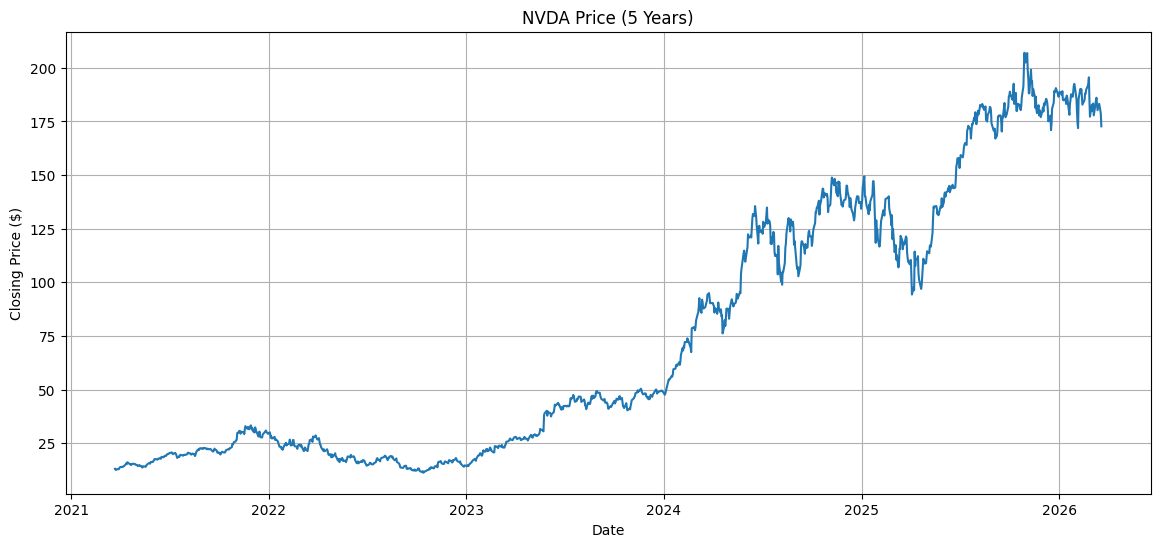

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.title("NVDA Price (5 Years)")
plt.show()

### Plot the 9, 21, and 100 EMAs

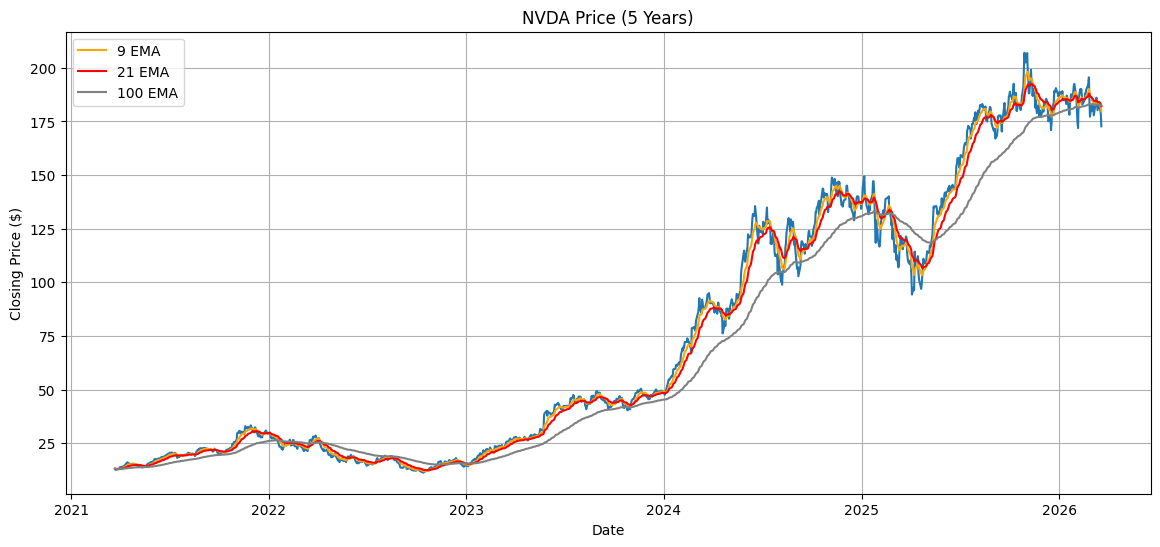

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.title("NVDA Price (5 Years)")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Use an 80/20 train/test split

In [6]:
df.shape

(1255, 9)

In [7]:
split = int(len(df) * 0.8)
train = df[:split]
test = df[split:]

In [8]:
print(train.shape)
train.head()

(1004, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
0,2021-03-23,13.037889,13.310951,12.988513,13.220927,222048000,13.037889,13.037889,13.037889
1,2021-03-24,12.611216,13.126168,12.604982,13.118188,245840000,12.952555,12.999101,13.029440
2,2021-03-25,12.503735,12.682784,12.241147,12.468075,295144000,12.862791,12.954068,13.019030
3,2021-03-26,12.806969,12.823926,12.342390,12.522935,363968000,12.851626,12.940695,13.014831
4,2021-03-29,12.915696,13.029659,12.668070,12.788018,273520000,12.864440,12.938422,13.012868


In [9]:
print(test.shape)
test.head()

(251, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
1004,2025-03-21,117.672264,117.962197,115.392803,116.912449,266498500,117.290448,119.532422,127.400670
1005,2025-03-24,121.381401,122.191208,119.311881,119.851755,228452500,118.108638,119.700511,127.281477
1006,2025-03-25,120.661568,121.261425,118.891980,120.521601,167447200,118.619224,119.787880,127.150390
1007,2025-03-26,113.733200,118.811997,112.683444,118.702030,293463300,117.642019,119.237454,126.884703
1008,2025-03-27,111.403755,114.423041,110.633940,111.323772,236902100,116.394367,118.525300,126.578149


### Normalize the dataset

In [10]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler has default param feature_range=(0,1)
scaler = MinMaxScaler()

train_close = train[["Close"]]
test_close = test[["Close"]]

# Scale training data
train_close_scaled = scaler.fit_transform(train_close)

# Scale testing data
prev_100_close = train_close.tail(100)
test_close = pd.concat([prev_100_close, test_close], ignore_index=True)
test_close_scaled = scaler.transform(test_close)

In [11]:
train_close_scaled

array([[0.01321278],
       [0.01012471],
       [0.00934682],
       ...,
       [0.75408149],
       [0.76920436],
       [0.77651251]], shape=(1004, 1))

In [12]:
test_close_scaled[:10]

array([[0.93466889],
       [0.94284402],
       [0.9354648 ],
       [0.94074596],
       [0.92692778],
       [0.87932373],
       [0.89842328],
       [0.90312586],
       [0.93105157],
       [0.97228921]])

### Create training sequences

In [13]:
x_train = []
y_train = []

# For each price x, grab the 100 prices before it and add them as a singular (list) element to x_train. Add price x as an element to y_train.
for i in range(100, train_close_scaled.shape[0]):
    x_train.append(train_close_scaled[i - 100 : i])
    y_train.append(train_close_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(904, 100, 1)
(904,)


### Create testing sequences

In [14]:
x_test = []
y_test = []

for i in range(100, test_close_scaled.shape[0]):
    x_test.append(test_close_scaled[i - 100 : i])
    y_test.append(test_close_scaled[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(251, 100, 1)
(251,)


### Build LSTM model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [16]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], 1)))

model.add(LSTM(units=50, activation="relu", return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation="relu", return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation="relu", return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [17]:
import tensorflow as tf

In [18]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

model.fit(x_train, y_train, epochs=100)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0736 - mean_absolute_error: 0.1937
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0155 - mean_absolute_error: 0.0876
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0099 - mean_absolute_error: 0.0637
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0100 - mean_absolute_error: 0.0631
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0072 - mean_absolute_error: 0.0542
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0085 - mean_absolute_error: 0.0578
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0073 - mean_absolute_error: 0.0541
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0057 - mean_absolute_error: 0.0481
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0075 - mean_absolute_error: 0.0574
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0069 - mean_absolute_error: 0.0507
Epoch 11/100
29/29 ━━━━━━━━━━